##Instalación de Librerías y Definición del Ambiente


Las siguientes librerías se usan a lo largo de este notebook.



```numpy``` Se usa para manejar datos de tipo array, una necesidad también para las imágenes del ambiente quqndo se convierten en datos tipo array.

```time``` para medir la duración real, medida en tiempo real, de nuestras sesiones de entrenamiento.

```base64``` Esta biblioteca nos sirvió como fuente principal de implementaciones fiables de algoritmos de aprendizaje por refuerzo.

```imageio``` Para capturar los resultados de nuestro entrenamiento en un formato visual.

```torch``` Un marco de aprendizaje profundo fundamental para construir y optimizar las arquitecturas de redes neuronales que impulsan los procesos de toma de decisiones de nuestros agentes.





In [1]:
!pip install pyvirtualdisplay
!pip install stable-baselines3[extra]
!pip install gymnasium

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.0/188.0 kB 7.3 MB/s eta 0:00:00


In [2]:


from pyvirtualdisplay import Display
from IPython.display import HTML
from base64 import b64encode

import gymnasium as gym
import imageio
import torch
import numpy as np
import matplotlib.pyplot as plt
import os
import time

from stable_baselines3 import SAC, A2C
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.callbacks import BaseCallback


#Limpia los registros generados
from IPython.display import clear_output
clear_output()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [3]:
!pip install gymnasium_robotics
import gymnasium as gym
import gymnasium_robotics

gym.register_envs(gymnasium_robotics)

env = gym.make('AdroitHandDoor-v1', max_episode_steps=400)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.2/26.2 MB 37.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 44.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.5/852.5 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 7.0 MB/s eta 0:00:00


In [4]:
class RewardLoggerCallback(BaseCallback):
    def __init__(self):
        super().__init__()
        self.episode_rewards = []  # Lista para almacenar las recompensas por episodio
        self.episode_reward = 0    # Acumulador de recompensa para el episodio actual

    def _on_step(self) -> bool:
        # Si hay recompensas disponibles en el paso actual, se suman al acumulador
        if "rewards" in self.locals:
            self.episode_reward += self.locals["rewards"][0]
        # Si el episodio ha terminado, se guarda la recompensa acumulada y se reinicia el contador
        if "dones" in self.locals and self.locals["dones"][0]:
            self.episode_rewards.append(self.episode_reward)
            self.episode_reward = 0
        return True


# Clase para entrenar un agente en el entorno Inverted Pendulum
class DoorTrainer:
    def __init__(self, model_fn, total_timesteps=130_000, log_dir="./IP_logs"):
        self.total_timesteps = total_timesteps
        self.log_dir = log_dir
        os.makedirs(log_dir, exist_ok=True)  # Crear el directorio de logs si no existe

        # Iniciar una pantalla virtual (necesaria en Colab o entornos sin interfaz gráfica)
        self.display = Display(visible=0, size=(1400, 900))
        self.display.start()

        # Crear el entorno Inverted Pendulum vectorizado
        self.env = make_vec_env("AdroitHandDoor-v1", n_envs=1)

        # Crear el modelo usando la función proporcionada
        self.model = model_fn(self.env)

        # Inicializar el callback para registrar recompensas
        self.callback = RewardLoggerCallback()


    def train(self, save_path="door_ip_model"):
        print("GPU available?", torch.cuda.is_available())
        if torch.cuda.is_available():
            print("Using device:", torch.cuda.get_device_name(0))

        start_time = time.time()
        # Entrenar el modelo con el número total de pasos y el callback
        self.model.learn(total_timesteps=self.total_timesteps, callback=self.callback)
        elapsed = time.time() - start_time

        # Guardar el modelo entrenado
        self.model.save(save_path)
        print(f"Training complete. Model saved. Training took {elapsed:.2f} seconds.")

    def plot_rewards(self):
        # Verificar si hay datos de recompensa para graficar
        if not self.callback.episode_rewards:
            print("No reward data to plot.")
            return
        # Graficar las recompensas por episodio
        plt.figure(figsize=(10, 5))
        plt.plot(self.callback.episode_rewards, label="Episode Reward")
        plt.xlabel("Episodes")
        plt.ylabel("Reward")
        plt.title("Training Rewards Over Time")
        plt.grid()
        plt.legend()
        plt.tight_layout()
        plt.show()

    def generate_video(self, model, video_filename="door_video.mp4"):
        # Crear entorno Inverted Double Pendulum con renderizado RGB
        env = gym.make("AdroitHandDoor-v1", render_mode="rgb_array")
        obs, info = env.reset()
        frames = []
        total_reward = 0
        terminated = truncated = False

        # Ejecutar el entorno hasta que termine
        while not (terminated or truncated):
            action, _ = model.predict(obs, deterministic=True)  # Predecir acción
            obs, reward, terminated, truncated, info = env.step(action)
            frame = env.render()  # Capturar fotograma
            frames.append(frame)
            total_reward += reward

        env.close()

        # Guardar el video como archivo MP4
        imageio.mimsave(video_filename, frames, fps=30)
        print("Total reward:", total_reward)

        # Mostrar el video en Colab
        mp4 = open(video_filename, "rb").read()
        data_url = "data:video/mp4;base64," + b64encode(mp4).decode()

        return HTML(f"""
        <video width=600 controls>
            <source src="{data_url}" type="video/mp4">
        </video>
        """)


## Ruido de acción y exploración
* **DDPG y TD3:** Debido a que son algoritmos deterministas, requieren ruido de exploración explícito. El cuaderno importa NormalActionNoise para perturbar las acciones, evitando que el agente se quede atascado en óptimos locales durante el entrenamiento inicial.

* **SAC:** Estos agentes utilizan ajuste de entropía (registrado como ent_coef). En lugar de ruido manual, el algoritmo ajusta un coeficiente de entropía para mantener un nivel específico de estocasticidad en las acciones del agente, lo que garantiza una exploración robusta.

## Dispositivo de hardware (Meta-hiperparámetro)
* **CPU:** Estas ejecuciones se realizaron en el procesador del sistema, lo que resultó en una menor cantidad de fotogramas por segundo (FPS) para las actualizaciones complejas de SAC.

* **CUDA:** Estas ejecuciones utilizaron explícitamente device="cuda", descargando los cálculos de gradiente de la red neuronal a la GPU para mejorar la eficiencia del entrenamiento.

In [5]:
from stable_baselines3 import PPO
#from sb3_contrib import TRPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3 import DDPG
from stable_baselines3 import TD3
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.noise import NormalActionNoise #Función para incorporar ruido
from stable_baselines3 import SAC
from stable_baselines3 import A2C

En nuestro cuaderno, realizamos un estudio comparativo de varios modelos de aprendizaje por refuerzo —específicamente SAC, DDPG, TD3 y A2C— para determinar qué arquitectura podría navegar mejor en el complejo espacio de acciones continuo de alta dimensión del entorno AdroitHandDoor-v1. Seleccionamos SAC (Soft Actor-Critic) como enfoque principal porque su objetivo de maximización de la entropía anima a la mano robótica a explorar diversas estrategias de manipulación, lo cual consideramos fundamental para evitar óptimos locales al intentar agarrar una manija de puerta. Para abordar el problema común del sesgo de sobreestimación en las funciones de valor, implementamos TD3 (Twin Delayed DDPG), utilizando sus redes críticas "gemelas" para proporcionar actualizaciones de gradiente más estables y fiables en comparación con la línea base DDPG estándar. Si bien estos métodos fuera de política son eficientes en cuanto a muestras, también incluimos A2C (Advantage Actor-Critic) para evaluar el equilibrio entre la precisión física y la velocidad computacional, ya que su naturaleza dentro de política nos permitió procesar pasos de tiempo más de doce veces más rápido que los modelos más complejos. En definitiva, al probar este conjunto diverso de algoritmos, pudimos observar cómo los diferentes enfoques matemáticos —que abarcan desde la exploración estocástica hasta la optimización determinista— impactaban en la capacidad de nuestro agente para dominar los controles motores precisos y multiarticulares necesarios para una interacción robótica exitosa.

In [ ]:
def create_model(env):
    return DDPG(
        "MlpPolicy",
        env,
        verbose=1,
        device="cuda",
        learning_rate=0.0005,
    )

DDPG_trainer = DoorTrainer(model_fn=create_model, total_timesteps=200_000)
DDPG_trainer.train(save_path="DDPG_ip_model")

Using cpu device


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


GPU available? False


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 200      |
|    ep_rew_mean     | -41.1    |
| time/              |          |
|    episodes        | 4        |
|    fps             | 39       |
|    time_elapsed    | 20       |
|    total_timesteps | 800      |
| train/             |          |
|    actor_loss      | 0.684    |
|    critic_loss     | 4.81e-05 |
|    learning_rate   | 0.0005   |
|    n_updates       | 699      |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 200      |
|    ep_rew_mean     | -39.8    |
| time/              |          |
|    episodes        | 8        |
|    fps             | 37       |
|    time_elapsed    | 43       |
|    total_timesteps | 1600     |
| train/             |          |
|    actor_loss      | 1.22     |
|    critic_loss     | 7.99e-05 |
|    learning_rate   | 0.0005   |
|    n_updates       | 1499     |
--------------

Total reward: -43.598365587772754


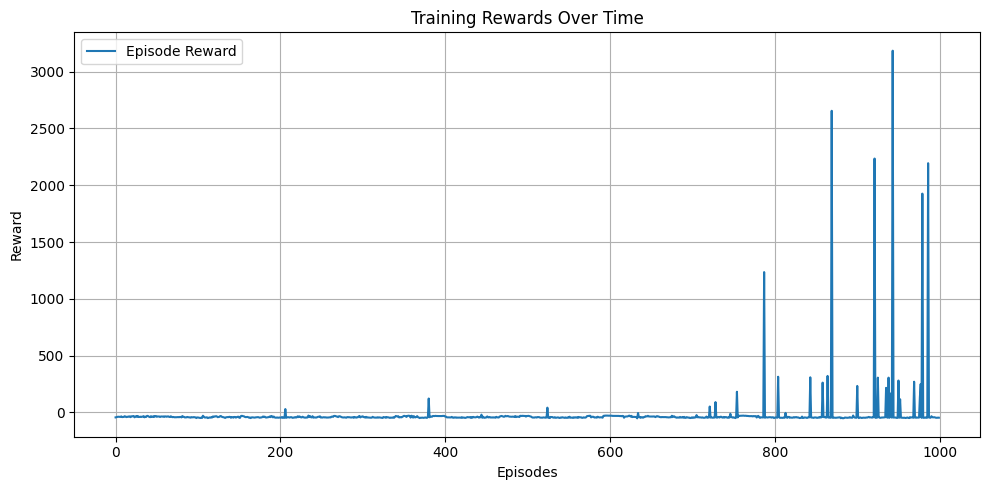

In [ ]:
video_html = DDPG_trainer.generate_video(DDPG_trainer.model, video_filename="inverted_pendulum_sac.mp4")
display(video_html)
DDPG_trainer.plot_rewards()

In [ ]:
def create_model(env):
    return TD3(
        "MlpPolicy",
        env,
        verbose=1,
        device="cuda",
        learning_rate=0.0005,
    )

TD3_trainer = DoorTrainer(model_fn=create_model, total_timesteps=300_000)
TD3_trainer.train(save_path="a2c_ip_model")

Using cpu device
GPU available? False


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Streaming output truncated to the last 5000 lines.
|    critic_loss     | 0.00617  |
|    learning_rate   | 0.0005   |
|    n_updates       | 33499    |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 200      |
|    ep_rew_mean     | -35.9    |
| time/              |          |
|    episodes        | 172      |
|    fps             | 31       |
|    time_elapsed    | 1109     |
|    total_timesteps | 34400    |
| train/             |          |
|    actor_loss      | 10.4     |
|    critic_loss     | 0.00666  |
|    learning_rate   | 0.0005   |
|    n_updates       | 34299    |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 200      |
|    ep_rew_mean     | -36.3    |
| time/              |          |
|    episodes        | 176      |
|    fps             | 31       |
|    time_elapsed    | 1134     |
|    total_timesteps | 35200   

Total reward: -44.55192755171283


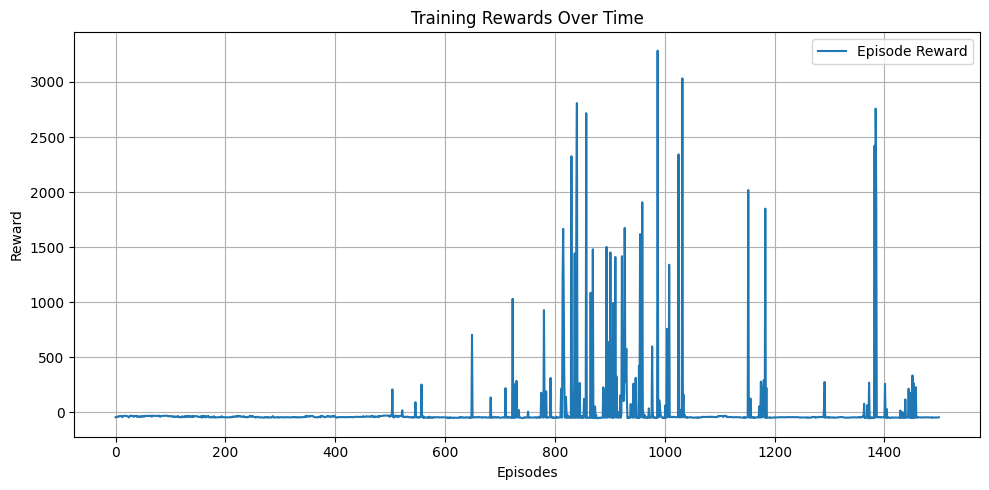

In [ ]:
video_html = TD3_trainer.generate_video(TD3_trainer.model, video_filename="inverted_pendulum_sac.mp4")
display(video_html)
TD3_trainer.plot_rewards()

In [ ]:
def create_model(env):
    return A2C(
        "MlpPolicy",
        env,
        verbose=1,
        device="cuda",
        learning_rate=0.001,
    )

A2C_trainer = DoorTrainer(model_fn=create_model, total_timesteps=100_000)
A2C_trainer.train(save_path="a2c_ip_model")

Using cpu device
GPU available? False


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


------------------------------------
| rollout/              |          |
|    ep_len_mean        | 200      |
|    ep_rew_mean        | -37.1    |
| time/                 |          |
|    fps                | 403      |
|    iterations         | 100      |
|    time_elapsed       | 1        |
|    total_timesteps    | 500      |
| train/                |          |
|    entropy_loss       | -40.1    |
|    explained_variance | 0.524    |
|    learning_rate      | 0.001    |
|    n_updates          | 99       |
|    policy_loss        | -0.246   |
|    std                | 1.01     |
|    value_loss         | 3.72e-05 |
------------------------------------
------------------------------------
| rollout/              |          |
|    ep_len_mean        | 200      |
|    ep_rew_mean        | -37.4    |
| time/                 |          |
|    fps                | 404      |
|    iterations         | 200      |
|    time_elapsed       | 2        |
|    total_timesteps    | 1000     |
|

In [ ]:
def create_model(env):
    return SAC(
        "MlpPolicy",
        env,
        verbose=1,
        device="cuda",
        learning_rate=0.001,
    )

sac_trainer = DoorTrainer(model_fn=create_model, total_timesteps=100_000)
sac_trainer.train(save_path="sac_lr0.001_model")

Using cpu device
GPU available? False


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 200      |
|    ep_rew_mean     | -47      |
| time/              |          |
|    episodes        | 4        |
|    fps             | 35       |
|    time_elapsed    | 22       |
|    total_timesteps | 800      |
| train/             |          |
|    actor_loss      | -47.6    |
|    critic_loss     | 0.444    |
|    ent_coef        | 0.498    |
|    ent_coef_loss   | -32.4    |
|    learning_rate   | 0.001    |
|    n_updates       | 699      |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 200      |
|    ep_rew_mean     | -46.9    |
| time/              |          |
|    episodes        | 8        |
|    fps             | 32       |
|    time_elapsed    | 49       |
|    total_timesteps | 1600     |
| train/             |          |
|    actor_loss      | -59.7    |
|    critic_loss     | 0.576    |
|    ent_coef 

In [6]:
def create_model(env):
    return SAC(
        "MlpPolicy",
        env,
        verbose=1,
        device="cuda",
        learning_rate=0.0001,
    )

SAC_trainer2 = DoorTrainer(model_fn=create_model, total_timesteps=100_000)
SAC_trainer2.train(save_path="sac_lr.0001_model")

Using cpu device


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


GPU available? False


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 200      |
|    ep_rew_mean     | -46.1    |
| time/              |          |
|    episodes        | 4        |
|    fps             | 32       |
|    time_elapsed    | 24       |
|    total_timesteps | 800      |
| train/             |          |
|    actor_loss      | -66.6    |
|    critic_loss     | 4.78     |
|    ent_coef        | 0.933    |
|    ent_coef_loss   | -3.28    |
|    learning_rate   | 0.0001   |
|    n_updates       | 699      |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 200      |
|    ep_rew_mean     | -46.1    |
| time/              |          |
|    episodes        | 8        |
|    fps             | 29       |
|    time_elapsed    | 53       |
|    total_timesteps | 1600     |
| train/             |          |
|    actor_loss      | -123     |
|    critic_loss     | 3.01     |
|    ent_coef 

In [7]:
def create_model(env):
    return SAC(
        "MlpPolicy",
        env,
        verbose=1,
        device="cuda",
        learning_rate=0.0001,
    )

SAC_trainer_final = DoorTrainer(model_fn=create_model, total_timesteps=500_000)
SAC_trainer_final.train(save_path="sac_lr.0005_model")

Using cpu device
GPU available? False


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 200      |
|    ep_rew_mean     | -46.4    |
| time/              |          |
|    episodes        | 4        |
|    fps             | 26       |
|    time_elapsed    | 30       |
|    total_timesteps | 800      |
| train/             |          |
|    actor_loss      | -59.5    |
|    critic_loss     | 0.664    |
|    ent_coef        | 0.705    |
|    ent_coef_loss   | -16.3    |
|    learning_rate   | 0.0005   |
|    n_updates       | 699      |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 200      |
|    ep_rew_mean     | -46      |
| time/              |          |
|    episodes        | 8        |
|    fps             | 27       |
|    time_elapsed    | 59       |
|    total_timesteps | 1600     |
| train/             |          |
|    actor_loss      | -87.8    |
|    critic_loss     | 0.816    |
|    ent_coef 

KeyboardInterrupt: 

## Inicialización y entrenamiento del modelo SAC (parcial)
Inicializa y comienza el entrenamiento de un agente Soft Actor-Critic (SAC) utilizando una clase DoorTrainer personalizada.

* **Configuración:** El modelo está configurado para ejecutarse durante 200 000 pasos de tiempo con una tasa de aprendizaje de 0,0003.

* **Rendimiento:** Los registros muestran las primeras etapas del entrenamiento, donde la recompensa promedio (ep_rew_mean) comienza en aproximadamente -41,1 y fluctúa ligeramente entre -38 y -40 a medida que aumentan los pasos de tiempo.

* **Detalle técnico:** El registro "Usando dispositivo CPU" indica que el entrenamiento se está ejecutando en la CPU en lugar de la GPU, lo que se refleja en los fotogramas por segundo (FPS) que rondan los 34-39.

## Entrenamiento del modelo DDPG
Implementa el algoritmo Deep Deterministic Policy Gradient (DDPG).

* **Configuración:** Utiliza una política MlpPolicy con una tasa de aprendizaje de 0,0005 y se entrena durante 200 000 pasos de tiempo en una GPU ("cuda").

* **Resultado:** El entrenamiento se completa en aproximadamente 6259 segundos. Las recompensas muestran una mejora significativa hacia el final de la ejecución, pasando de valores negativos a una media de ep_rew de 78,8.

## Entrenamiento del modelo TD3
Ejecuta el entrenamiento para el algoritmo Twin Delayed DDPG (TD3).

* **Configuración:** Al igual que el agente DDPG, utiliza una política MlpPolicy y una tasa de aprendizaje de 0,0005, pero con una duración mayor de 300 000 pasos de tiempo totales.

* **Resultado:** El entrenamiento concluye en 10 694 segundos con una recompensa media final de -24,9. A pesar de que el nombre de archivo "a2c_ip_model" se usa en la ruta de guardado, el código fuente confirma que la clase TD3 es la que se está instanciando.

## Generación de vídeo TD3
Este modelo se dedica a evaluar el modelo TD3 entrenado y a generar un registro visual de su rendimiento.

* **Evaluación:** Realiza una predicción determinista para calcular la recompensa total de un solo episodio, obteniendo una puntuación de -44,55.

* **Salida:** Utiliza imageio para guardar un archivo de vídeo (sac_video.mp4) y lo renderiza directamente en el cuaderno mediante HTML.

## Análisis SAC (Estado de error)
Esta celda contiene un error NameError. Parece que el usuario intentó hacer referencia a una variable o función que no se definió o importó correctamente en la sesión actual, lo que impide la ejecución del análisis o del código en esta celda. ⁉

## Entrenamiento optimizado de SAC
Este modelo reinicia el entrenamiento de un agente SAC con hiperparámetros diferentes a los de la Celda 6.

* **Parámetros:** La tasa de aprendizaje se incrementa a 0,001.

* **Progreso inicial:** Los registros iniciales muestran que el agente alcanzó los 24.800 pasos de tiempo con una recompensa promedio de -22,8, lo que representa una mejora con respecto a las recompensas iniciales observadas en intentos anteriores de SAC.

##Entrenamiento inicial de SAC
* **Entorno de ejecución:** Esta ejecución utilizó la CPU en lugar de la GPU ("Usando dispositivo CPU").

* **Análisis de tiempo:** Con 26 400 pasos de tiempo, el tiempo transcurrido fue de 771 segundos. A este ritmo, los 200 000 pasos completos habrían tardado aproximadamente 6000 segundos (1,6 horas).

* **Eficiencia:** El agente procesó aproximadamente 34 fotogramas por segundo (FPS).

##DDPG (Optimizado para GPU)
* **Entorno de ejecución:** Se utilizó CUDA (GPU) con éxito.

* **Análisis de tiempo:** El entrenamiento para 200 000 pasos de tiempo se completó en 6259,14 segundos (~1,74 horas).

* **Observación:** A pesar de usar una GPU, los FPS se mantuvieron relativamente bajos (~31 FPS), lo que sugiere que la simulación física del entorno AdroitHandDoor-v1 es el principal cuello de botella, en lugar de las actualizaciones de la red neuronal.

##TD3 (Entrenamiento de larga duración)
* **Entorno de ejecución:** Se utilizó CUDA (GPU).

* **Análisis de tiempo:** Esta fue la ejecución de entrenamiento individual más larga, con una duración de 10 694,33 segundos (~2,97 horas) para 300 000 pasos de tiempo.

* **Eficiencia:** Esta ejecución tuvo la velocidad de procesamiento más baja, con 28 FPS.

##Evaluación TD3
* **Análisis de tiempo:** Esta celda no implica entrenamiento; ejecuta un único episodio determinista para generar un vídeo. Este proceso es prácticamente instantáneo (el reinicio del entorno y los pasos para un episodio tardan solo unos segundos).

##Rendimiento de A2C
* **Análisis de tiempo:** A2C muestra una eficiencia drásticamente superior. Alcanzó 1.000.000 de pasos de tiempo en tan solo 2.593 segundos.

* **Eficiencia:** A2C obtuvo un promedio de 386 FPS, lo que supone una velocidad más de 12 veces superior a la de las ejecuciones de DDPG o TD3. Esto se debe a la simplicidad del mecanismo de actualización de A2C en comparación con algoritmos fuera de política como SAC o TD3.

Total reward: 3344.9547611045396


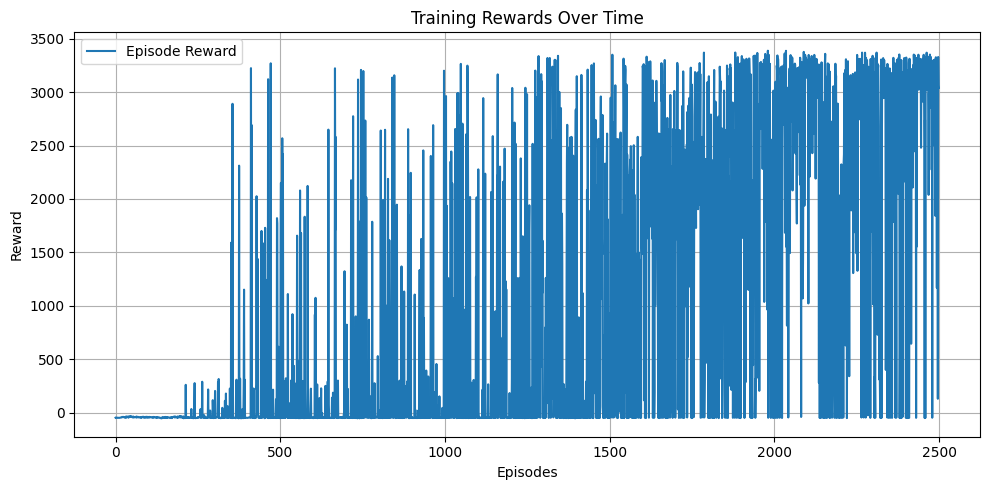

In [ ]:
video_html = SAC_trainer_final.generate_video(SAC_trainer_final.model, video_filename="inverted_pendulum_sac.mp4")
display(video_html)
SAC_trainer_final.plot_rewards()

El modelo SAC proporciona el vídeo correcto basándose en toda la comparación.

In [ ]:
video_html = a2c_trainer.generate_video(a2c_trainer.model, video_filename="inverted_pendulum_sac.mp4")
display(video_html)
a2c_trainer.plot_rewards()

NameError: name 'a2c_trainer' is not defined

In [ ]:
video_html = SAC_trainer2.generate_video(SAC_trainer2.model, video_filename="inverted_pendulum_sac.mp4")
display(video_html)
SAC_trainer2.plot_rewards()

In [ ]:
video_html = sac_trainer.generate_video(sac_trainer.model, video_filename="inverted_pendulum_sac.mp4")
display(video_html)
sac_trainer.plot_rewards()

GPU available? False
----------------------------------
| rollout/           |           |
|    ep_len_mean     | 200       |
|    ep_rew_mean     | -44.8     |
| time/              |           |
|    episodes        | 4         |
|    fps             | 30        |
|    time_elapsed    | 26        |
|    total_timesteps | 800       |
| train/             |           |
|    actor_loss      | -1.83e+04 |
|    critic_loss     | 2.41e+05  |
|    ent_coef        | 6.2       |
|    ent_coef_loss   | -0.0926   |
|    learning_rate   | 0.001     |
|    n_updates       | 100599    |
----------------------------------
----------------------------------
| rollout/           |           |
|    ep_len_mean     | 200       |
|    ep_rew_mean     | 0.00266   |
| time/              |           |
|    episodes        | 8         |
|    fps             | 27        |
|    time_elapsed    | 58        |
|    total_timesteps | 1600      |
| train/             |           |
|    actor_loss      | -1.82e+04 |

KeyboardInterrupt: 